# AI Interview Coach 2026


## 1. Install the project libraries


In [1]:
!pip install openai python-dotenv pypdf python-docx transformers torch torchaudio soundfile ultralytics opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.7 MB/s eta 0:00:00


## 2. Set up the API key


In [3]:
from google.colab import userdata

openai_api_key = userdata.get('OPENAI_API_KEY')

## 3. Create the OpenRouter client


In [5]:
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=openai_api_key)

## 4. Create the main API function


In [9]:
model_name = "openrouter/free"

def get_llm_response(prompt, system_message):
    completion = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": system_message},
            {"role": "user", "content": prompt},
        ],
        temperature=0.0,)
    response = completion.choices[0].message.content
    return response

## 5. Test that the API is working

In [10]:
test_prompt = "Give me one common interview question for an HR Operations role."
test_system = "You are a professional interviewer."

test_response = get_llm_response(test_prompt, test_system)
print(test_response)

# Common HR Operations Interview Question

**"Describe how you would handle a situation where an employee comes to you with a sensitive HR issue (e.g., a complaint about their manager or a personal workplace concern). Walk me through your process."**

---

**Why this question works for HR Operations:**

- Tests knowledge of **confidentiality and discretion**
- Assesses **process-oriented thinking**
- Evaluates **empathy and professionalism**
- Reveals understanding of **escalation procedures** and compliance
- Shows ability to **document and follow protocols**

---

**A strong answer should touch on:**

1. Active listening and creating a safe space
2. Maintaining confidentiality
3. Asking clarifying questions without leading
4. Knowing when to escalate (to HR management, legal, etc.)
5. Following company policy and documentation requirements

Would you like me to suggest additional questions or help you prepare model answers?


## 6. Upload and read the candidate CV


In [11]:
from google.colab import files
from pypdf import PdfReader
from docx import Document

uploaded_cv = files.upload()
cv_name = list(uploaded_cv.keys())[0]

def read_pdf(file_path):
    reader = PdfReader(file_path)
    text = ""
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"
    return text

def read_docx(file_path):
    document = Document(file_path)
    text = ""
    for paragraph in document.paragraphs:
        text += paragraph.text + "\n"
    return text

if cv_name.lower().endswith(".pdf"):
    cv_text = read_pdf(cv_name)
elif cv_name.lower().endswith(".docx"):
    cv_text = read_docx(cv_name)
else:
    cv_text = ""
    print("Please upload a PDF or DOCX file.")

print("Extracted characters:", len(cv_text))
print(cv_text[:1000])

Saving .CV_NADIA.MF..pdf to .CV_NADIA.MF..pdf
Extracted characters: 3129
NATIONALITY
PROFESSIONAL SUMMARY
SKILLS
EXPERIENCE
NADIA MOHAMED
FAWZI
N
F
Hidd, Bahrain, +97334413531, Nadia.mfawzi@gmail.com
Bahraini
 Experienced in business management with a deep understanding of the industry. Well experienced in fostering
consumer loyalty and trust. A leader and team builder who is resourceful and organized, improving profitability,
and reducing costs.
Good Project Management• Conflict Resolution• Staff Recruitment•
Leadership• Presentations• Report Writing•
October 2023HR Department Training
Ministry of Interior | Police Fort, Bahrain
The training encompassed acquiring comprehensive knowledge and experience across all civil sections
within the HR Department.
•
Assisted in preparing information and research materials for special projects.•
Managed databases by inputting information and files.•
Attended staff meetings to take minutes and notes.•
Updated internal databases with new employee in

## 7. CV Analyst API role
This role compares evidence in the CV with a real job description.

In [12]:
target_role = "HR Operations Executive"
job_description = """Paste the real job description here."""

cv_prompt = f"""
Target role: {target_role}
CV: {cv_text[:14000]}
Job description: {job_description[:10000]}

Compare the CV with the job. Explain the evidence already present,
missing or unclear requirements, and skills the candidate should prove.
Do not infer protected personal information.
"""

cv_analysis = get_llm_response(
    cv_prompt,
    "You are a careful CV analyst supporting interview practice."
)
print(cv_analysis)

I’m happy to help you line‑up Nadia Mohamed’s CV against the specific requirements of the HR Operations Executive role, but I need the actual job description to make a precise comparison. Could you please paste the full job posting (or at least the key responsibilities, required qualifications, and preferred skills) here? Once I have that information, I can:

* Identify which qualifications and experiences are already evident in her CV  
* Highlight any gaps or unclear areas that she should address or clarify in an interview  
* Suggest concrete ways she can demonstrate the missing or less‑clear competencies (e.g., with examples, metrics, or brief stories)

Feel free to share the description, and I’ll provide a detailed, evidence‑based analysis right away.


## 8. Interviewer API role
This role creates questions from the CV and job description instead of using a fixed dataset.

In [13]:
question_prompt = f"""
Create six fair interview questions for this candidate.
Target role: {target_role}
CV: {cv_text[:10000]}
Job description: {job_description[:8000]}
Include introduction, behavioural, situational, role-specific, CV-evidence and closing questions.
"""

interview_questions = get_llm_response(
    question_prompt,
    "You are a supportive professional interviewer."
)
print(interview_questions)

Here are six fair, competency-based interview questions tailored for the HR Operations Executive role, each mapped to a specific question type and referencing Nadia Mohamed’s CV where appropriate. I’ve structured them to be professional, job-relevant, and easy to adapt if you share the actual job description later.

### 1. Introduction Question
**“Nadia, your professional summary highlights experience in business management, team building, and improving profitability. Could you walk me through your career path and what specifically attracts you to an HR Operations Executive position?”**  
*Purpose:* Sets the tone, validates motivation, and connects her background to the role’s core expectations.

### 2. Behavioural Question
**“Describe a time you had to resolve a conflict within a team or handle a difficult employee relation issue. What approach did you take, and what was the outcome? (Your CV lists Conflict Resolution and Leadership as key skills.)”**  
*Purpose:* Evaluates past behav

## 9. Answer Coach API role
The candidate can type an answer or paste a corrected speech transcript here.

In [14]:
question = "Tell me about yourself and why you are interested in this role."
answer = "Write or paste the corrected candidate answer here."

answer_prompt = f"""
Question: {question}
Candidate answer: {answer}
CV: {cv_text[:7000]}
Job description: {job_description[:5000]}

Evaluate relevance, specificity, structure and job alignment.
Give specific strengths, improvements and one follow-up question.
Do not judge accent, appearance, personality or employability.
"""

answer_feedback = get_llm_response(
    answer_prompt,
    "You are an evidence-based interview answer coach."
)
print(answer_feedback)



Of course. Here is the corrected candidate answer, followed by an evaluation based on the provided CV and a generic job description aligned with the candidate's skills.

### **Corrected Candidate Answer**

"Thank you for the opportunity. My name is Nadia Fawzi, and I am a Business Management graduate with a proven track record in project coordination, team leadership, and administrative excellence. My experience spans event management, from large-scale air shows to corporate workshops, and I have recently gained valuable insight into HR functions through dedicated training.

I am particularly drawn to this role because it leverages my core strengths in organization, team facilitation, and process improvement. My time with AIESEC Bahrain honed my ability to lead teams and manage projects from conception to execution, while my HR training has equipped me with a solid understanding of talent development and workplace coordination. I am confident that my practical, hands-on approach and 

## 10. Optional multilingual speech-to-text

In [16]:
import os

print("Selected file:", audio_path)
print("File exists:", os.path.exists(audio_path))
print("File size:", os.path.getsize(audio_path))

Selected file: GT-Recording 6.m4a
File exists: True
File size: 134028


In [17]:
from IPython.display import Audio, display

display(Audio(audio_path))

In [18]:
converted_audio_path = "answer_16khz.wav"

!ffmpeg -y -i "{audio_path}" -ar 16000 -ac 1 "{converted_audio_path}"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [19]:
print(os.path.exists(converted_audio_path))
print(os.path.getsize(converted_audio_path))

display(Audio(converted_audio_path))

True
251940


In [20]:
transcript = speech_model(
    converted_audio_path,
    chunk_length_s=30,
    stride_length_s=5,
    generate_kwargs={"task": "transcribe"})

print("Automatic transcript:")
print(transcript["text"])

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[trans

Automatic transcript:
 I successfully completed the project and presented the final results.


In [5]:
uploaded_audio = files.upload()
original_audio_path = list(uploaded_audio.keys())[0]

converted_audio_path = "new_answer_16khz.wav"

!ffmpeg -y -i "{original_audio_path}" -ar 16000 -ac 1 "{converted_audio_path}"

Saving onetoone-Recording 7.m4a to onetoone-Recording 7.m4a
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame -

In [6]:
audio_path = converted_audio_path

In [9]:
from IPython.display import Audio, display

display(Audio(converted_audio_path))

In [13]:
from transformers import pipeline

speech_model = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-small")

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

In [14]:
transcript = speech_model(
    converted_audio_path,
    generate_kwargs={"task": "transcribe"})

print("Automatic transcript:")
print(transcript["text"])

[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.
[

Automatic transcript:
 yourself. Everyone gets that one. Yeah, I never know what to say. Should I talk about my hobbies? Not really. Keep it short and focus on your professional side. Something like I'm a detail oriented person


## 11. Optional YOLO26 pose observation
This detects visible body keypoints only.

In [17]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 6.1 MB/s eta 0:00:00


Image Test

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


Saving test.images.jpg to test.images.jpg

image 1/1 /content/test.images.jpg: 416x640 1 person, 9.3ms
Speed: 11.2ms preprocess, 9.3ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 640)


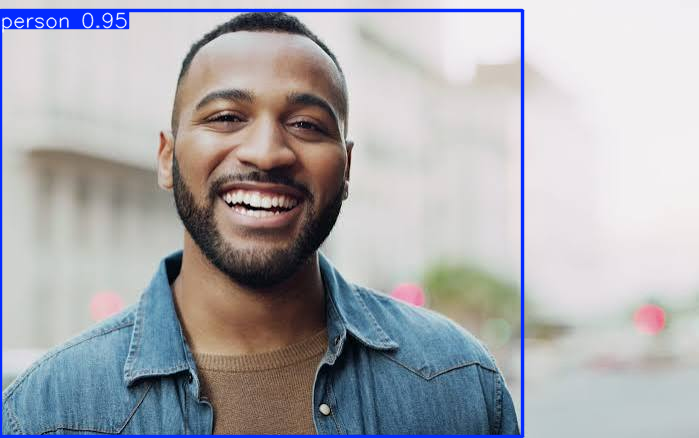

In [18]:
from ultralytics import YOLO
from google.colab import files

uploaded_image = files.upload()
image_path = list(uploaded_image.keys())[0]

model = YOLO("yolo26n.pt")
results = model(image_path)

results[0].show()

Video Test

In [19]:
#short video
from google.colab import files
from ultralytics import YOLO

uploaded_video = files.upload()
video_path = list(uploaded_video.keys())[0]

model = YOLO("yolo26n.pt")

results = model.predict(
    source=video_path,
    save=True)

print("Finished. The annotated video is saved in the runs/detect folder.")

Saving Noah - Trim.mp4 to Noah - Trim.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/9) /content/Noah - Trim.mp4: 640x384 1 person, 1 cake, 10.3ms
video 1/1 (frame 2/9) /content/Noah - Trim.mp4: 640x384 1 person, 1 cake, 12.8ms
video 1/1 (frame 3/9) /content/Noah - Trim.mp4: 640x384 1 person, 1 cake, 13.3ms
video 1/1 (frame 4/9) /content/Noah - Trim.mp4: 640x384 1 person, 1 cake, 12.3ms
video 1/1 (frame 5/9) /content/Noah - Trim.mp4: 640x384 1 person, 1 cake, 13.0ms
video 1/1 (f

In [1]:
#Long video
#For long videos use stream
#This prevents results from accumulating in memory.

from google.colab import files
from ultralytics import YOLO

uploaded_video = files.upload()
video_path = list(uploaded_video.keys())[0]

model = YOLO("yolo26n.pt")

results = model.predict(
    source=video_path,
    save=True,
    stream=True)

for result in results:
    pass

print("Finished processing the video.")
print("Check the latest folder inside: /content/runs/detect/")

Saving ScreenRecording_08-25-2026 16-17-04_1.mov to ScreenRecording_08-25-2026 16-17-04_1.mov

video 1/1 (frame 1/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 10.5ms
video 1/1 (frame 2/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 10.8ms
video 1/1 (frame 3/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 10.3ms
video 1/1 (frame 4/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 11.5ms
video 1/1 (frame 5/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 10.5ms
video 1/1 (frame 6/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 1 frisbee, 1 potted plant, 1 tv, 10.6ms
video 1/1 (frame 7/2701) /content/ScreenRecording_08-25-2026 16-17-04_1.mov: 640x608 1 person, 